In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score
)

In [2]:
df = pd.read_csv('application_train.csv')

In [3]:
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

In [4]:
print('Shape',df.shape)

Shape (307511, 122)


In [5]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,1.000020e+05,189145.500000,278202.000000,367142.500000,4.562550e+05
TARGET,307511.0,0.080729,0.272419,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
CNT_CHILDREN,307511.0,0.417052,0.722121,0.000000e+00,0.000000,0.000000,1.000000,1.900000e+01
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,2.565000e+04,112500.000000,147150.000000,202500.000000,1.170000e+08
AMT_CREDIT,307511.0,599025.999706,402490.776996,4.500000e+04,270000.000000,513531.000000,808650.000000,4.050000e+06
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1.615500e+03,16524.000000,24903.000000,34596.000000,2.580255e+05
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,4.050000e+04,238500.000000,450000.000000,679500.000000,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,0.020868,0.013831,2.900000e-04,0.010006,0.018850,0.028663,7.250800e-02
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-2.522900e+04,-19682.000000,-15750.000000,-12413.000000,-7.489000e+03
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-1.791200e+04,-2760.000000,-1213.000000,-289.000000,3.652430e+05


In [8]:
df.DAYS_EMPLOYED.value_counts().head()

,count
DAYS_EMPLOYED,
365243,55374
-200,156
-224,152
-230,151
-199,151


In [9]:
df.DAYS_BIRTH.value_counts().head()

,count
DAYS_BIRTH,
-13749,43
-13481,42
-10020,41
-18248,41
-15771,40


In [10]:
# Fix the placeholder 365243 replace with np.nan
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243,np.nan)

In [11]:
# 1: Convert days to years (invert negative values)
df['AGE'] = -df['DAYS_BIRTH'] / 365
df['YEARS_EMPLOYED'] = -df['DAYS_EMPLOYED'] / 365

# 2: Drop the original columns to avoid redundancy
df = df.drop(columns=['DAYS_BIRTH', 'DAYS_EMPLOYED'])

In [12]:
df.AGE.isnull().sum()

np.int64(0)

#### **EDA**

In [13]:
# Correlation of all features with Target variable

correlations = df.corr(numeric_only=True)['TARGET'].sort_values(ascending=False)
print('Most Positive Correlations:\n', correlations.head(15))
print('\nMost Negative Correlations:\n', correlations.tail(15))

Most Positive Correlations:
 TARGET                         1.000000
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
DAYS_REGISTRATION              0.041975
OWN_CAR_AGE                    0.037612
LIVE_CITY_NOT_WORK_CITY        0.032518
DEF_30_CNT_SOCIAL_CIRCLE       0.032248
DEF_60_CNT_SOCIAL_CIRCLE       0.031276
FLAG_WORK_PHONE                0.028524
Name: TARGET, dtype: float64

Most Negative Correlations:
 LIVINGAREA_AVG               -0.032997
FLOORSMIN_MEDI               -0.033394
FLOORSMIN_AVG                -0.033614
ELEVATORS_MEDI               -0.033863
ELEVATORS_AVG                -0.034199
REGION_POPULATION_RELATIVE   -0.037227
AMT_GOODS_PRICE              -0.039645
FLOORSMAX_MODE               -0.043226


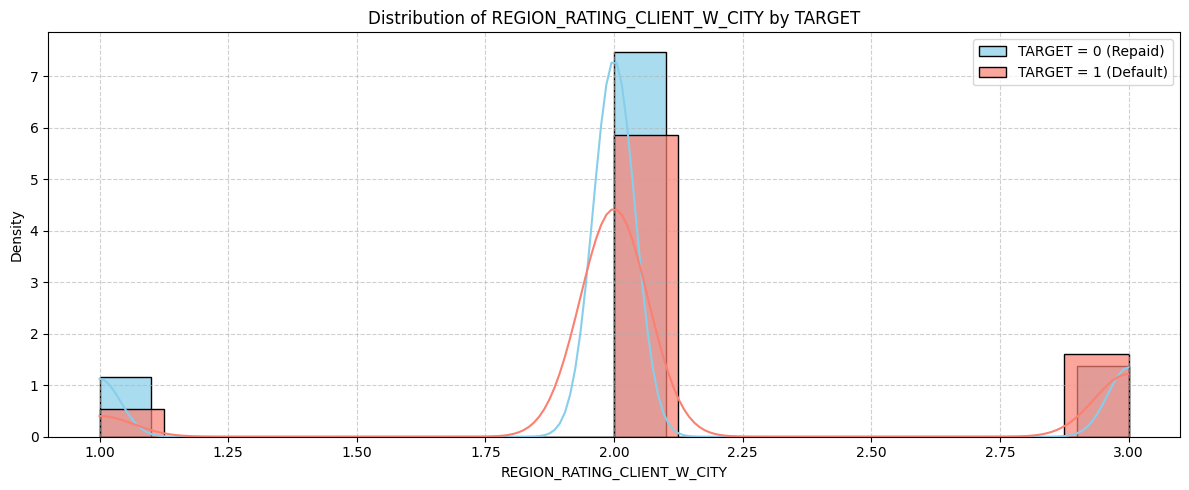

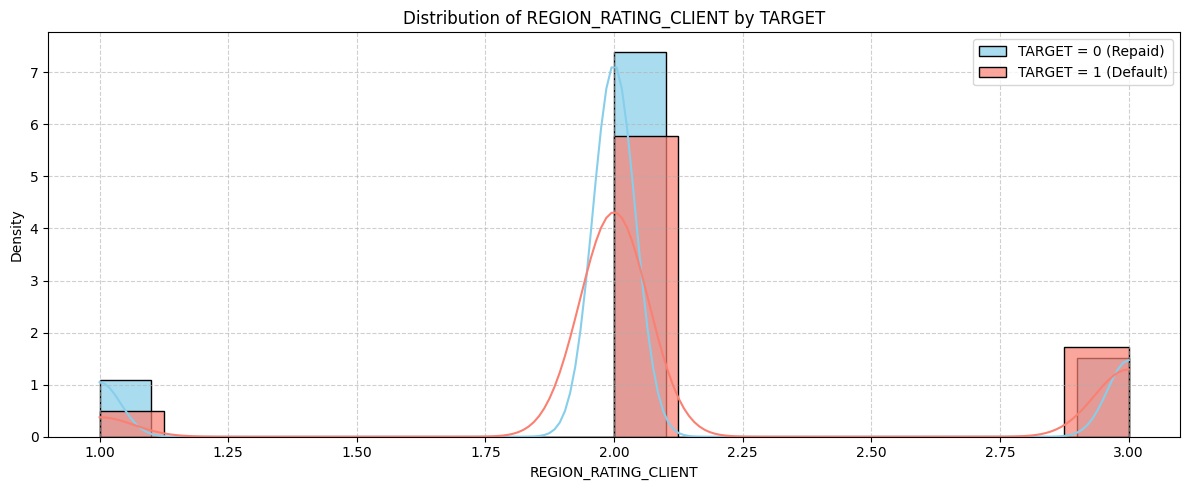

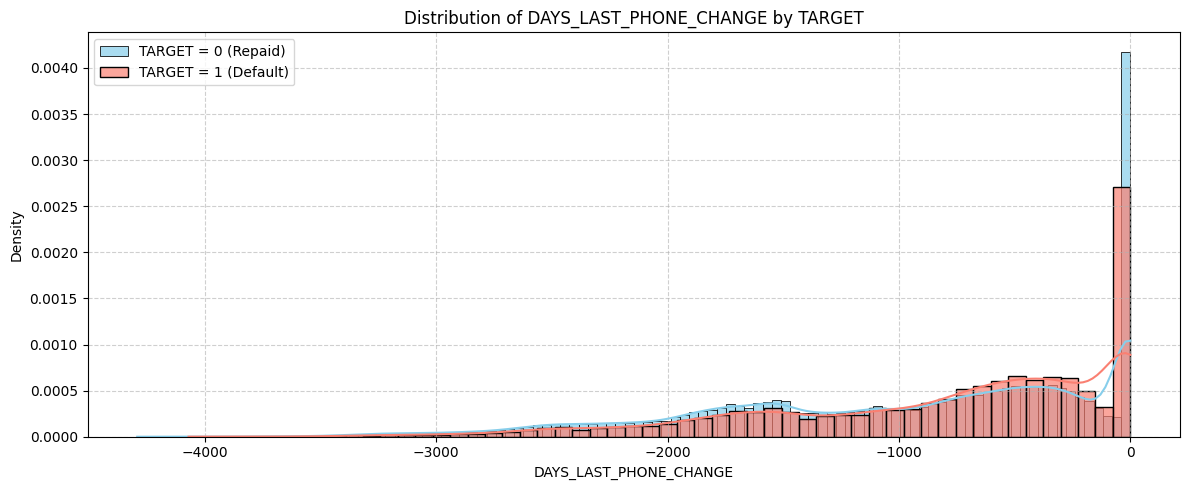

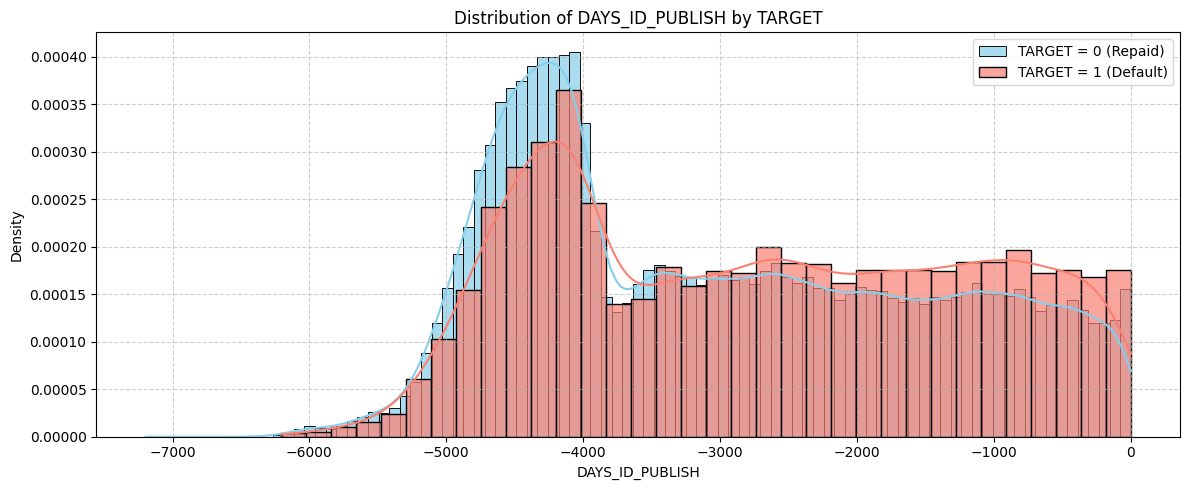

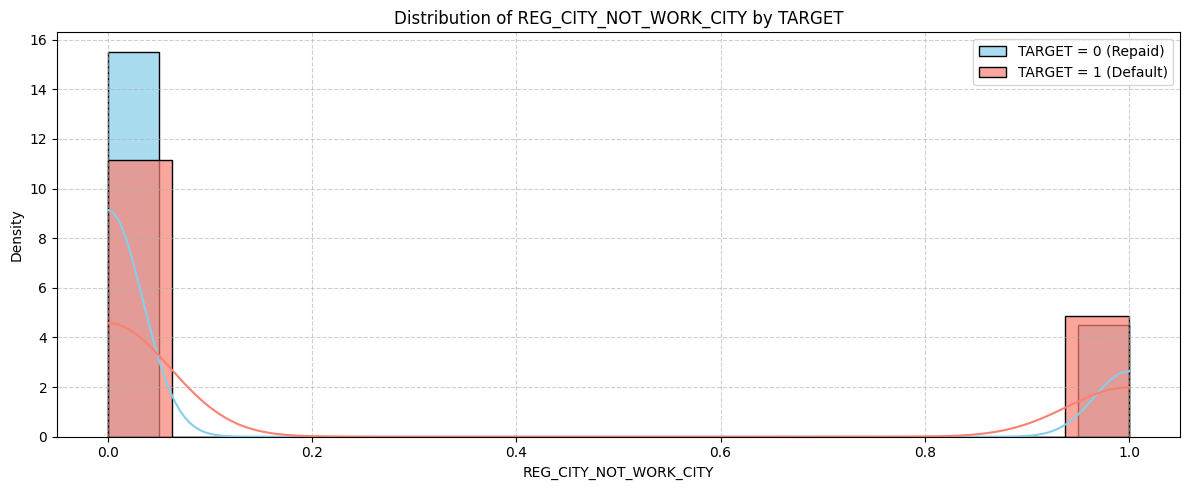

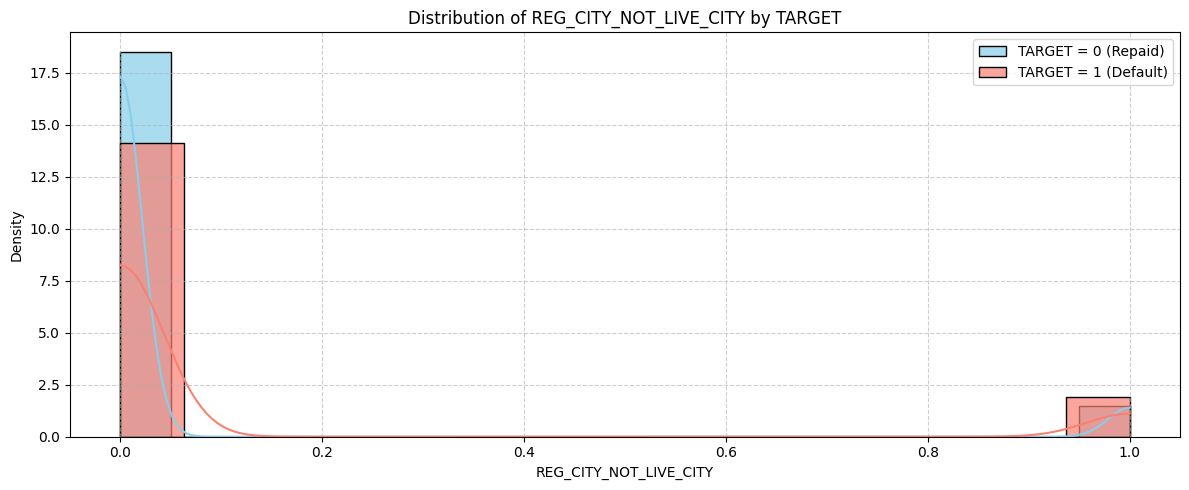

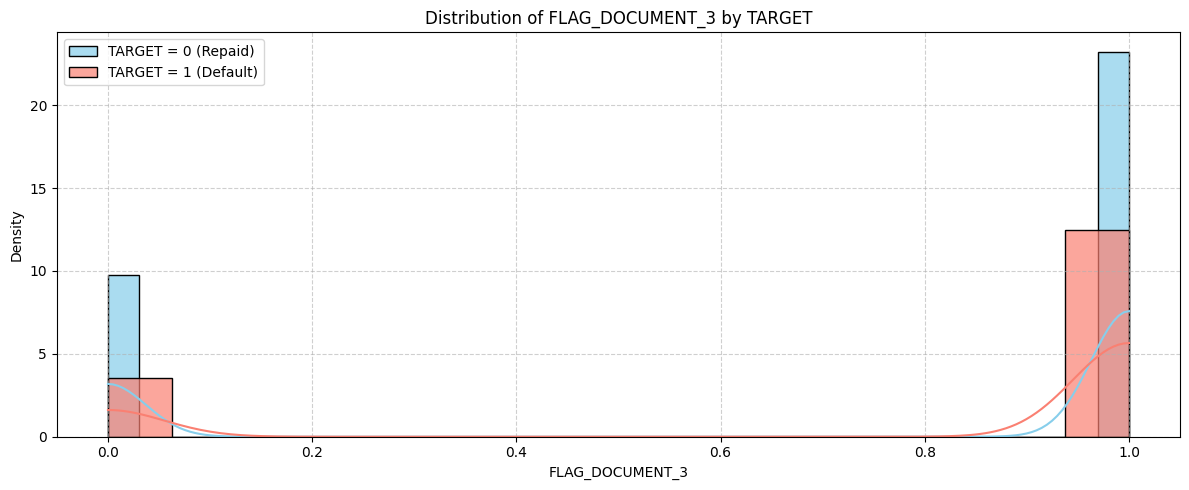

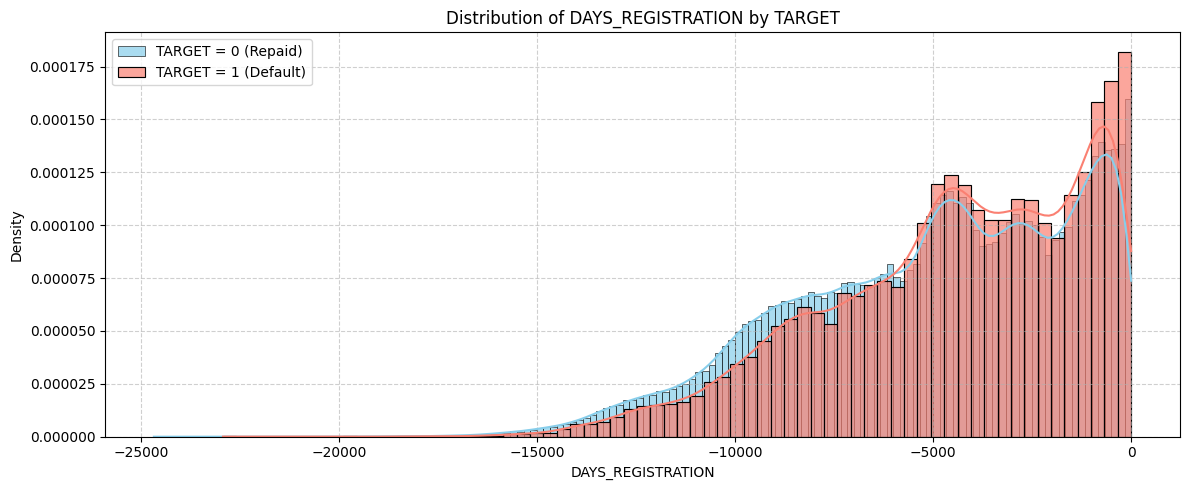

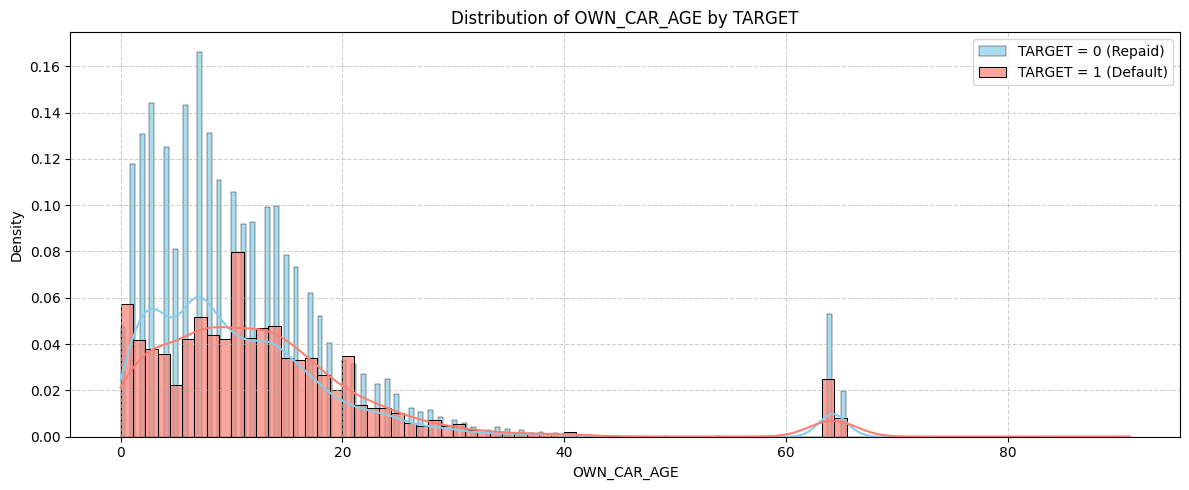

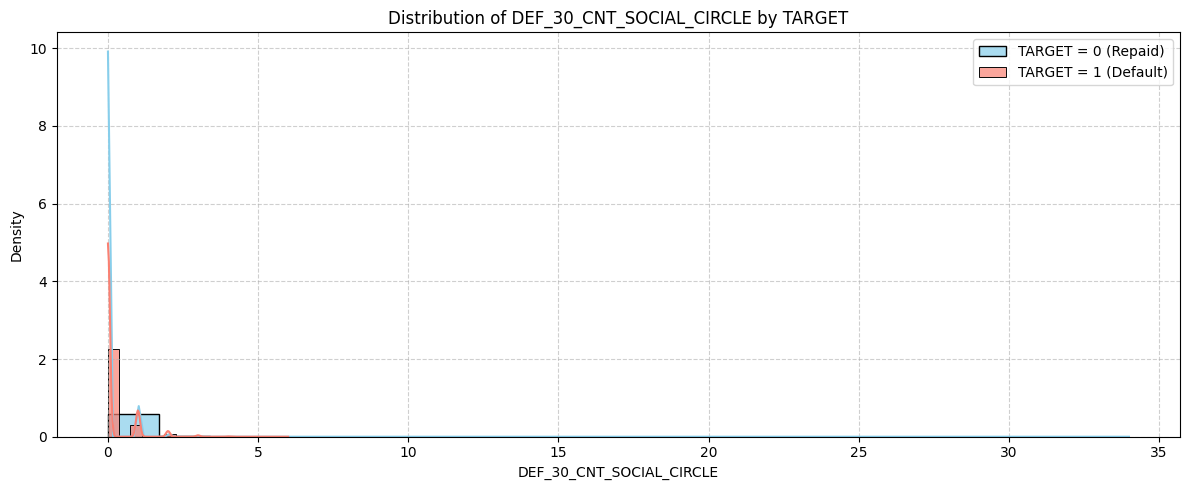

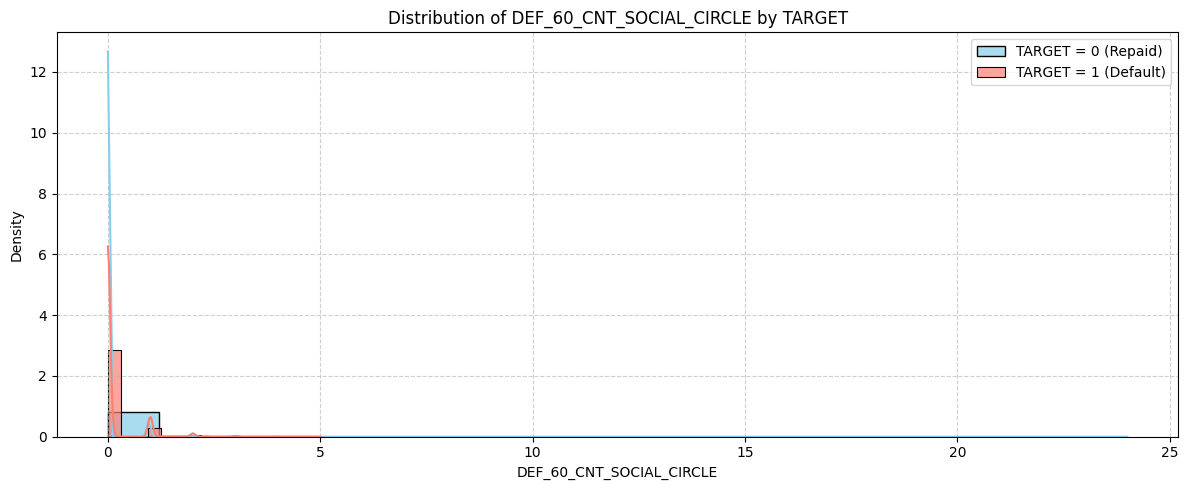

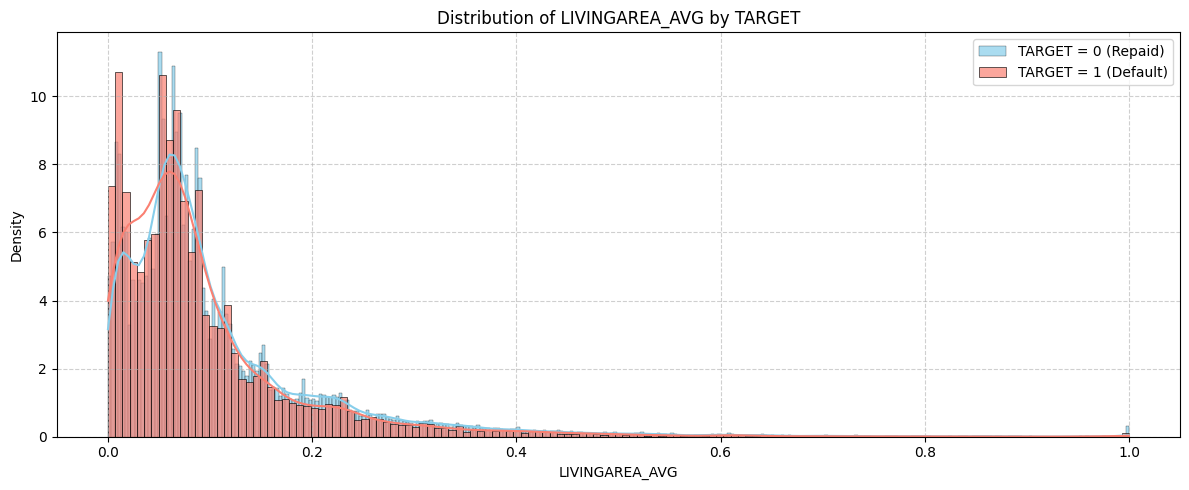

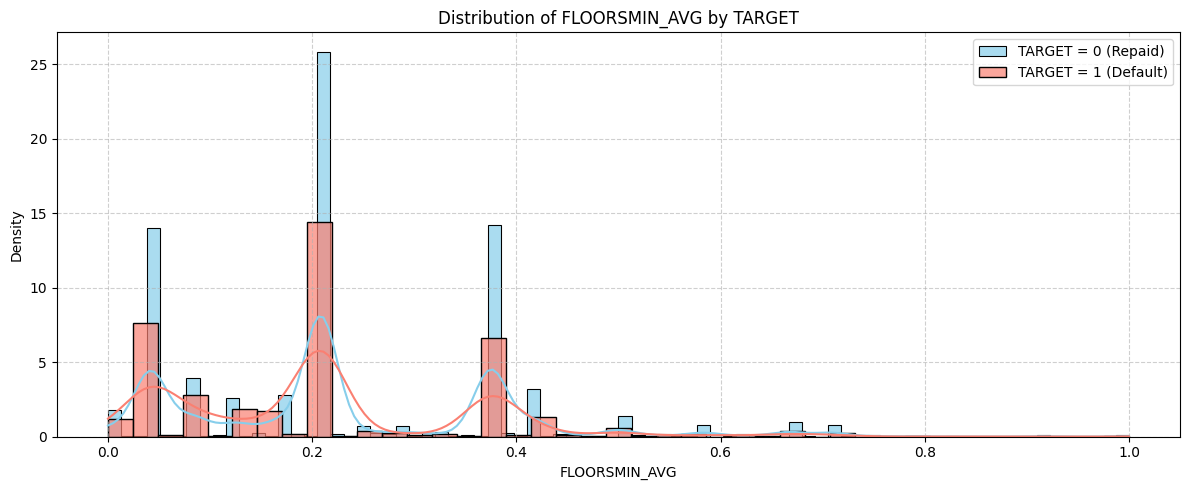

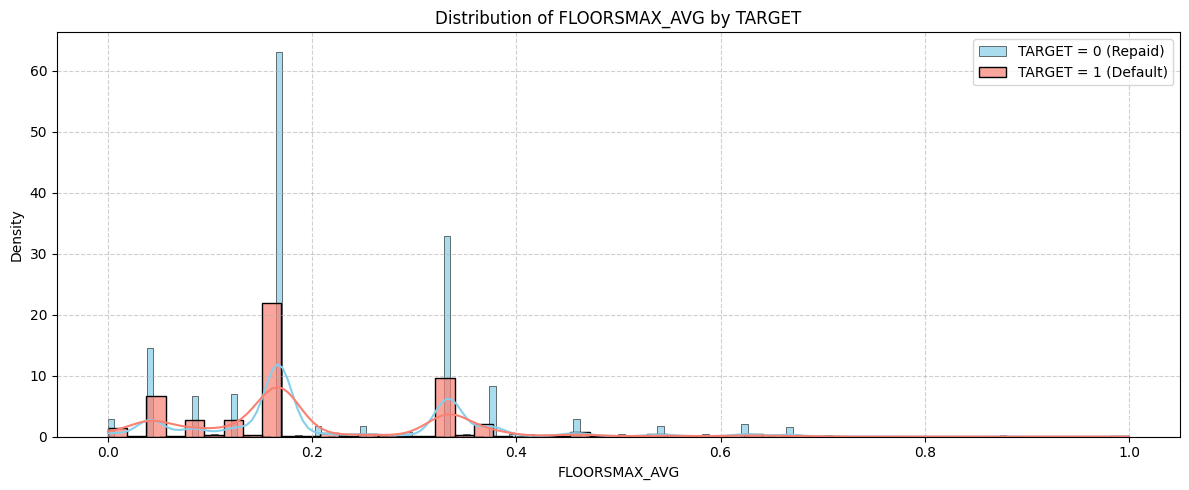

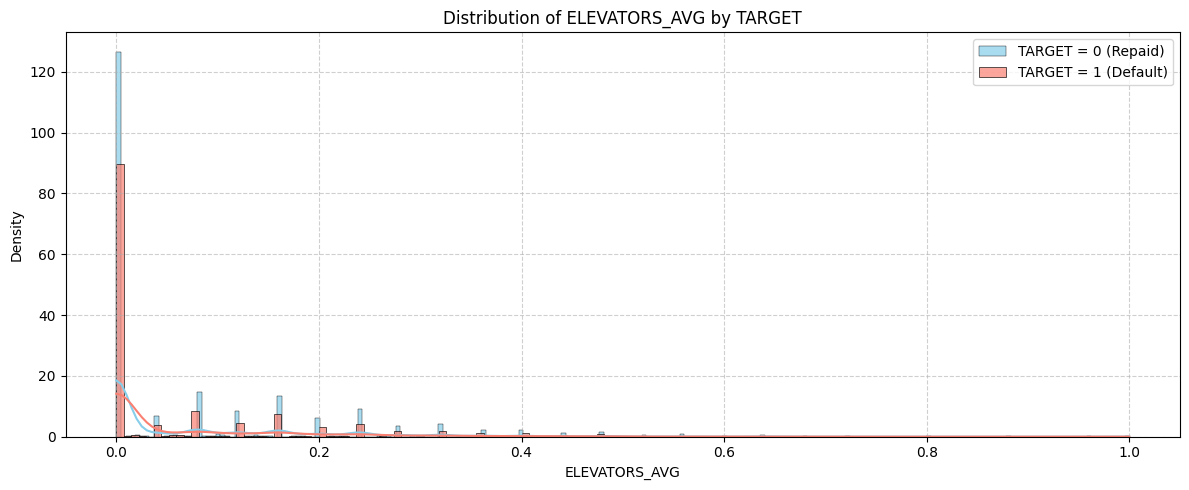

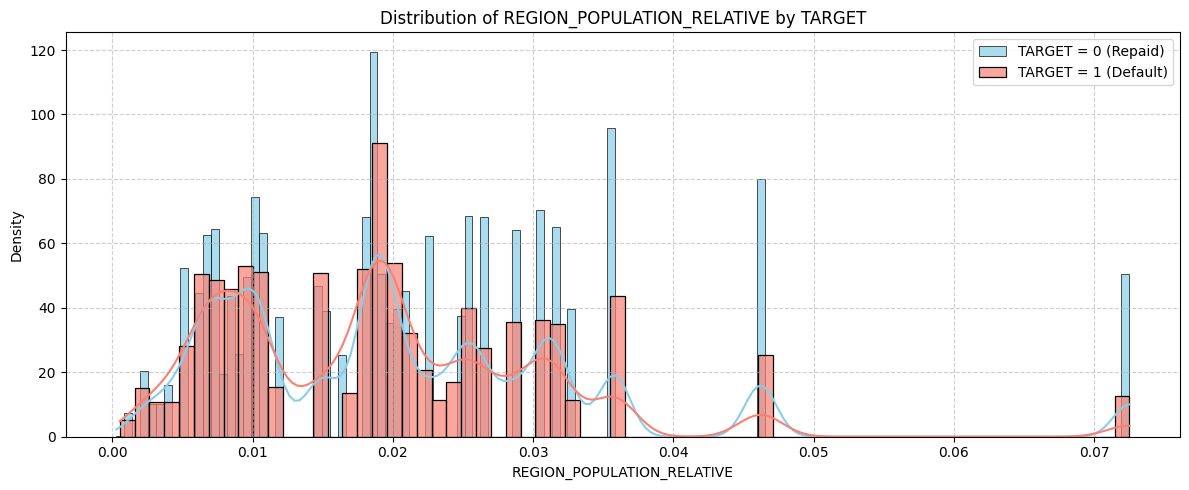

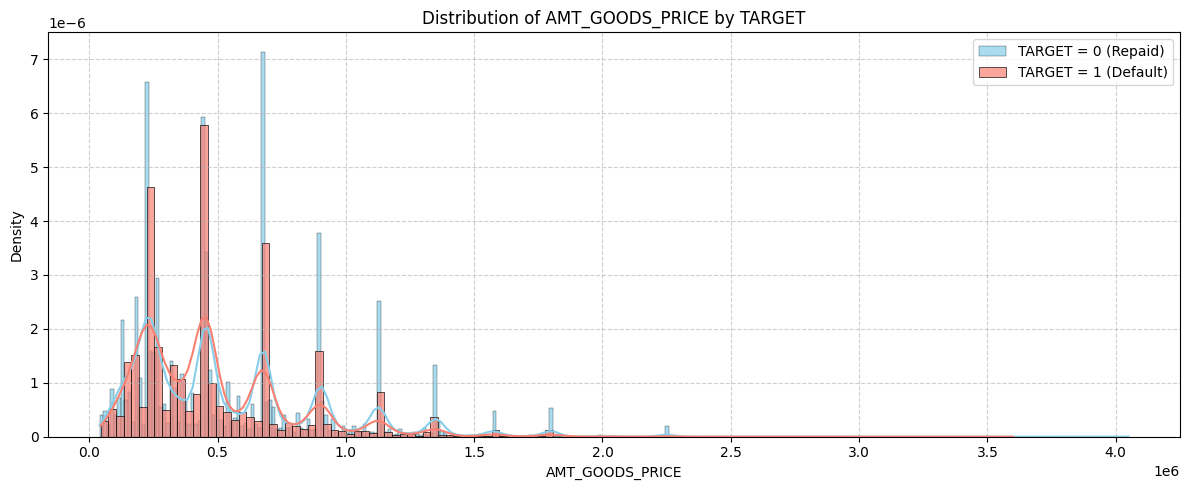

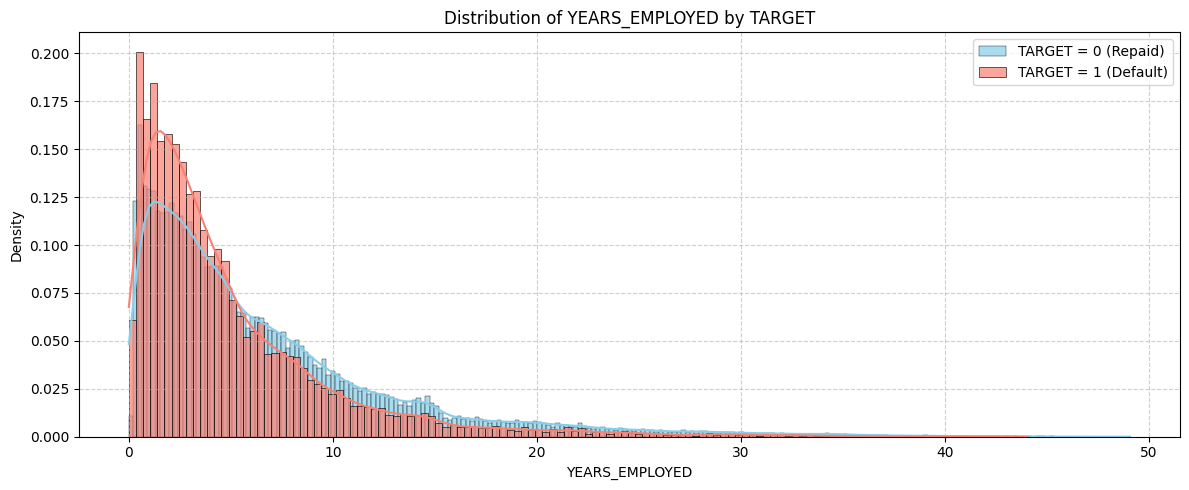

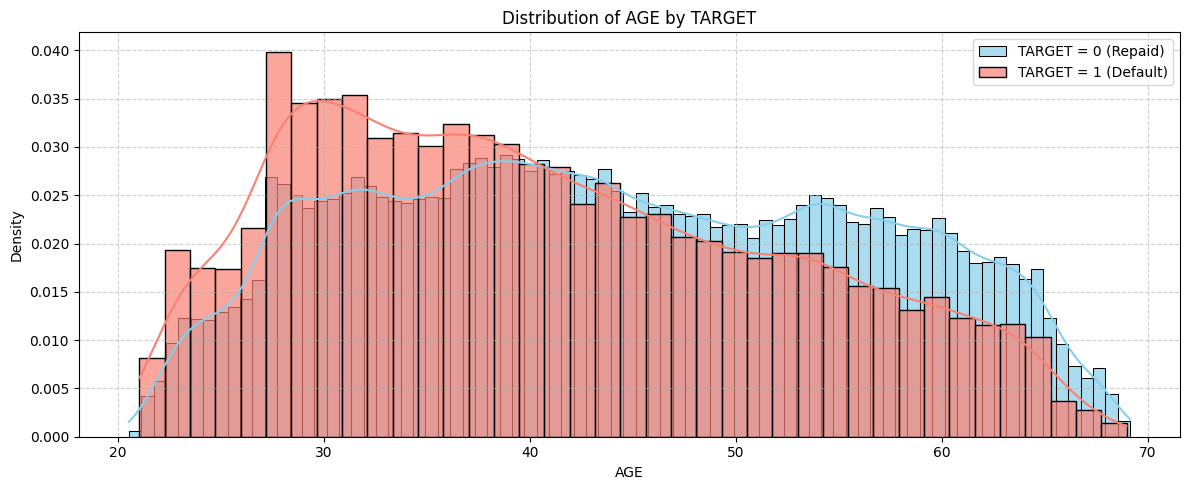

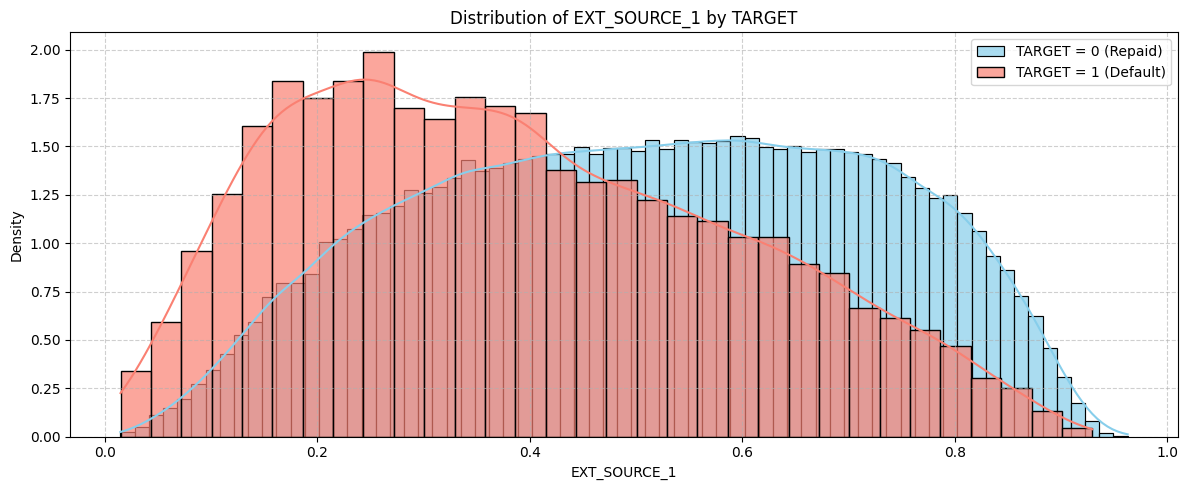

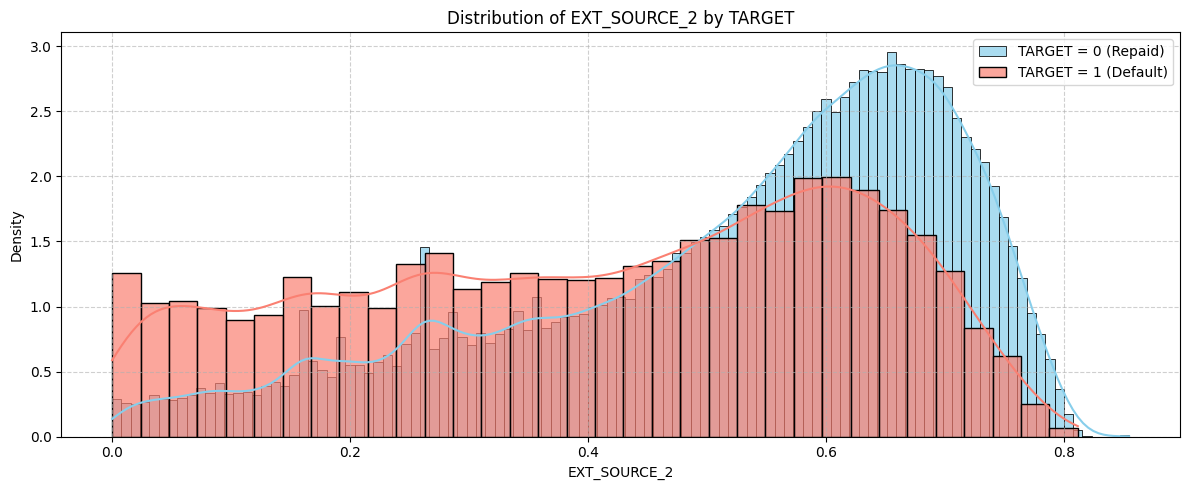

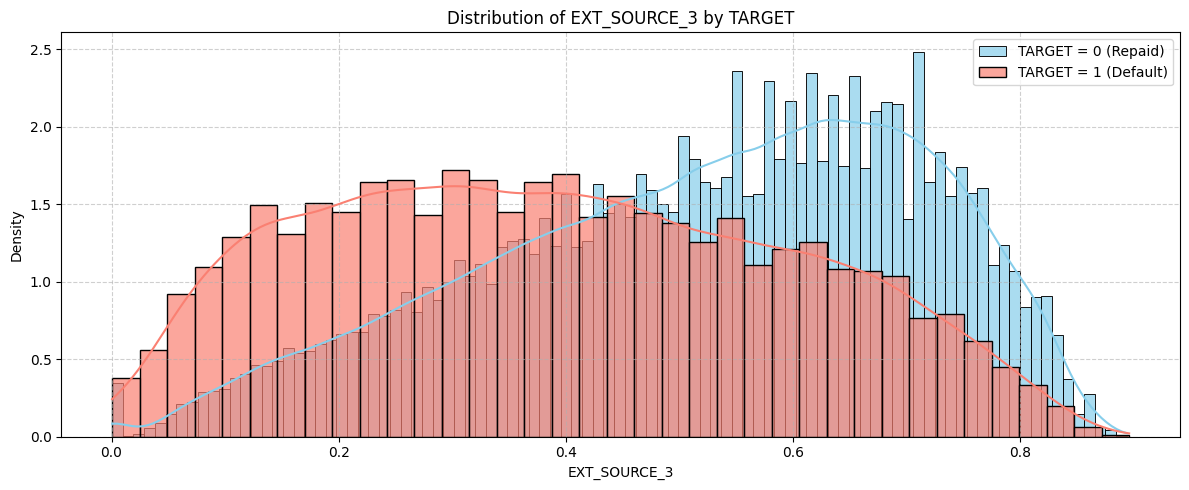

In [14]:
# Explore Distributions of Selected Features

selected_features = [
    'REGION_RATING_CLIENT_W_CITY',
    'REGION_RATING_CLIENT',
    'DAYS_LAST_PHONE_CHANGE',
    'DAYS_ID_PUBLISH',
    'REG_CITY_NOT_WORK_CITY',
    'REG_CITY_NOT_LIVE_CITY',
    'FLAG_DOCUMENT_3',
    'DAYS_REGISTRATION',
    'OWN_CAR_AGE',
    'DEF_30_CNT_SOCIAL_CIRCLE',
    'DEF_60_CNT_SOCIAL_CIRCLE',

    'LIVINGAREA_AVG',
    'FLOORSMIN_AVG',
    'FLOORSMAX_AVG',
    'ELEVATORS_AVG',
    'REGION_POPULATION_RELATIVE',
    'AMT_GOODS_PRICE',
    'YEARS_EMPLOYED',
    'AGE',
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3'
]

for feature in selected_features:
    plt.figure(figsize=(12, 5))
    sns.histplot(df[df['TARGET'] == 0][feature].dropna(), label='TARGET = 0 (Repaid)', kde=True, color='skyblue', stat='density', alpha=0.7)
    sns.histplot(df[df['TARGET'] == 1][feature].dropna(), label='TARGET = 1 (Default)', kde=True, color='salmon', stat='density', alpha=0.7)
    plt.title(f'Distribution of {feature} by TARGET')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

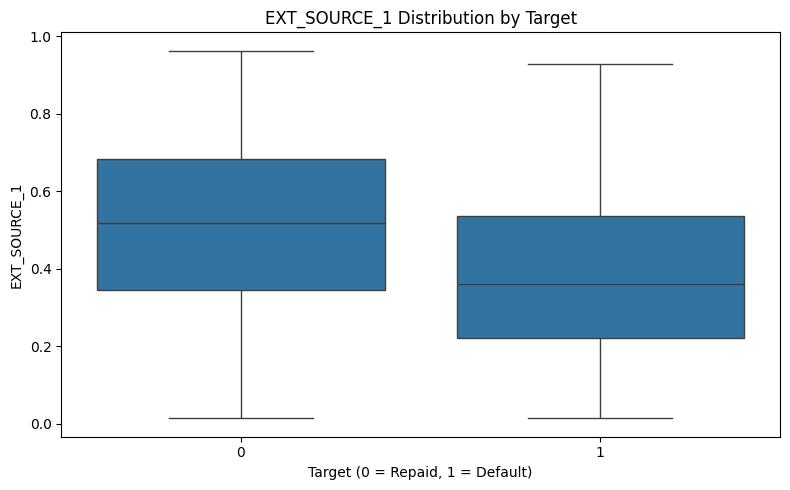

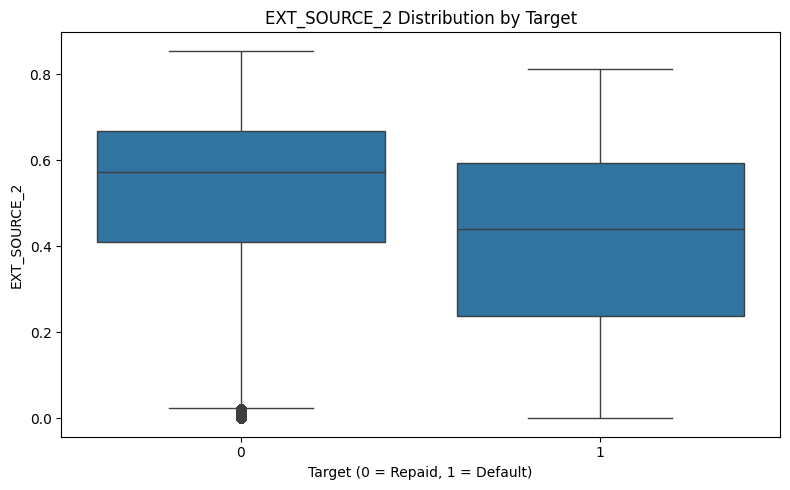

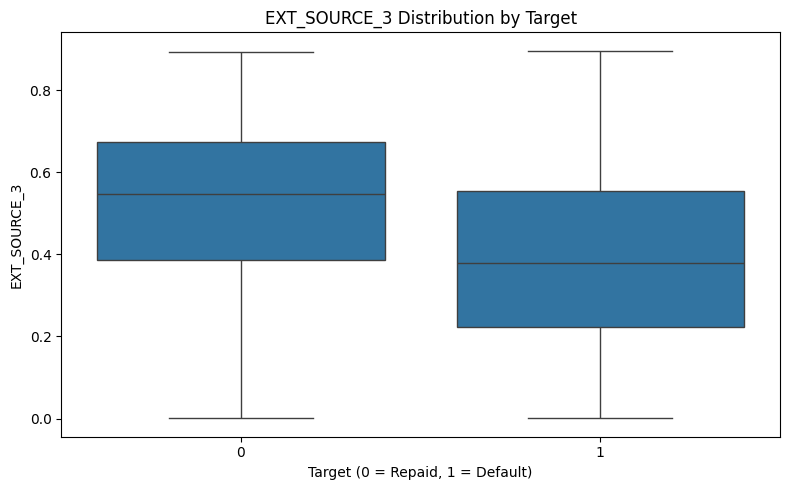

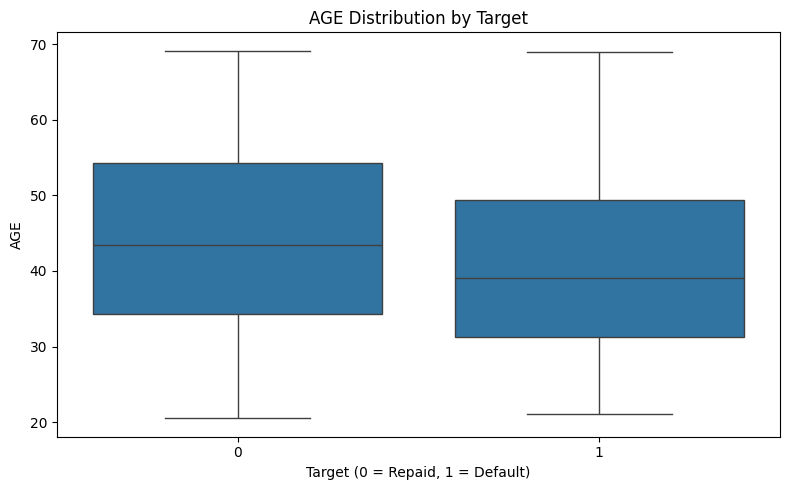

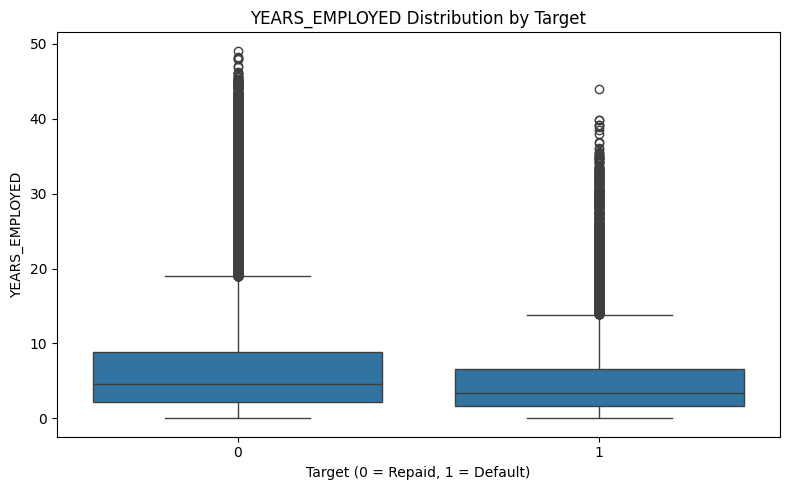

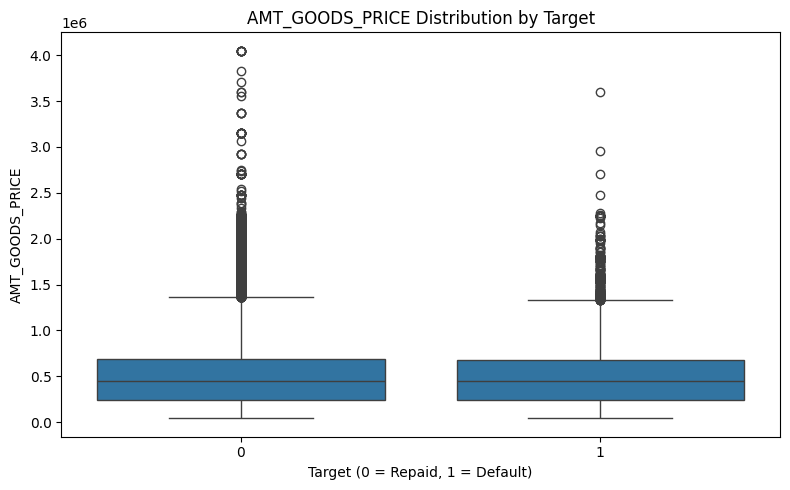

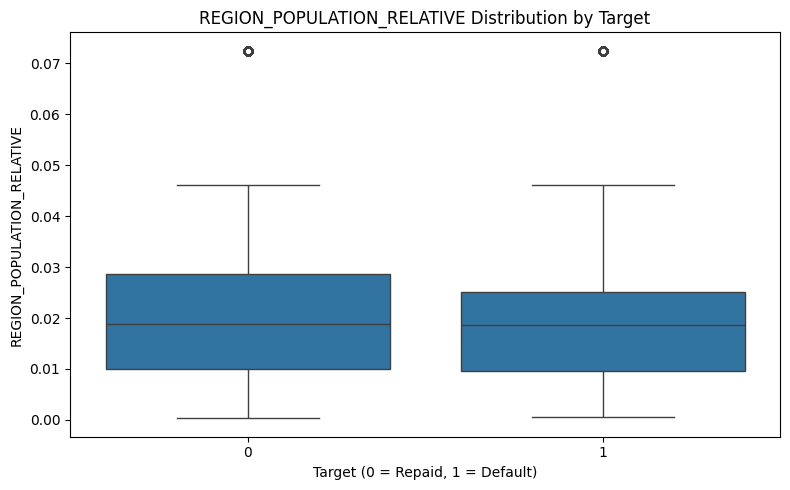

In [15]:
boxplot_features = [
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3',
    'AGE',
    'YEARS_EMPLOYED',
    'AMT_GOODS_PRICE',
    'REGION_POPULATION_RELATIVE'
]

for feature in boxplot_features:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x='TARGET',
        y=feature
    )

    plt.title(f'{feature} Distribution by Target')
    plt.xlabel('Target (0 = Repaid, 1 = Default)')
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

In [16]:
# Categorical Features
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

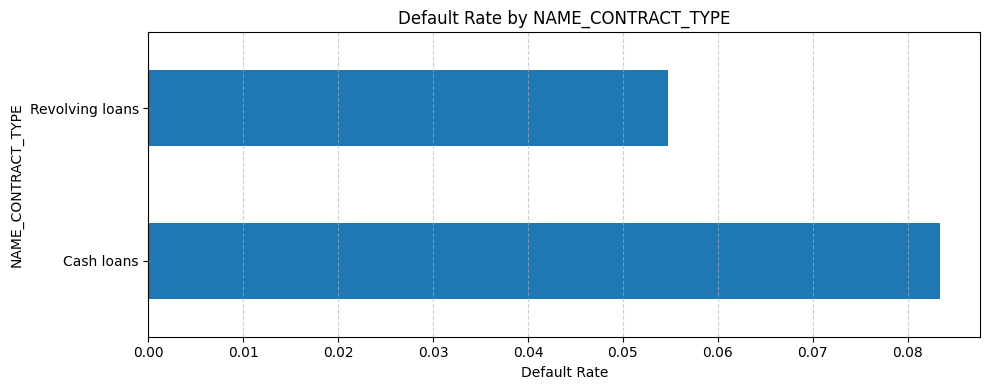

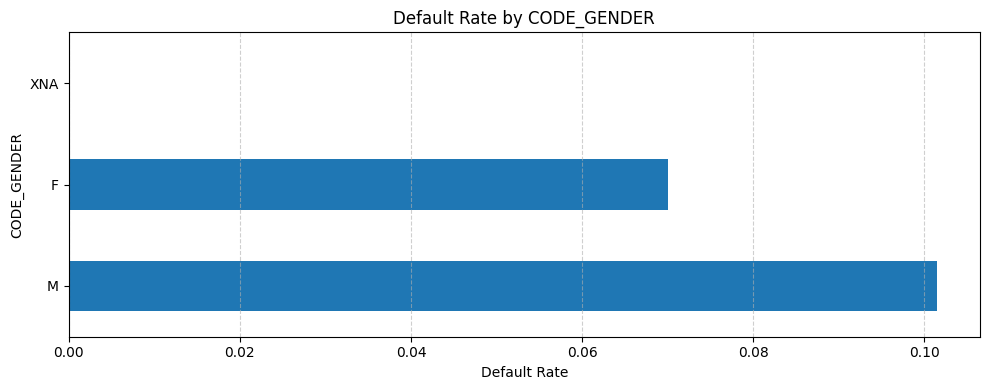

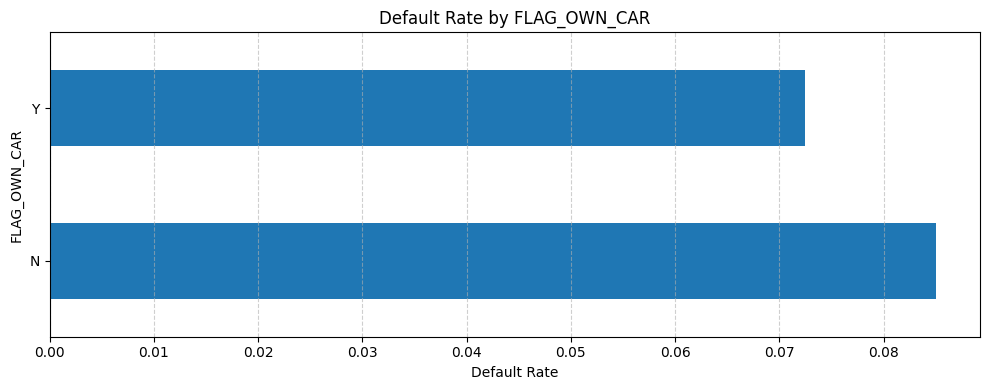

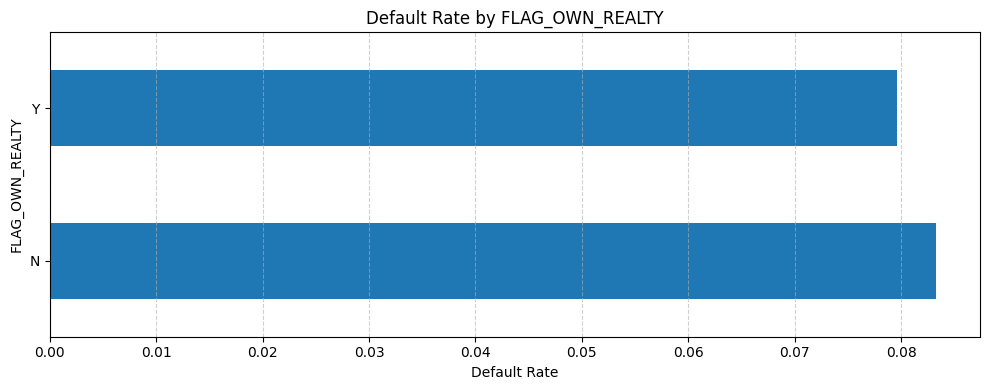

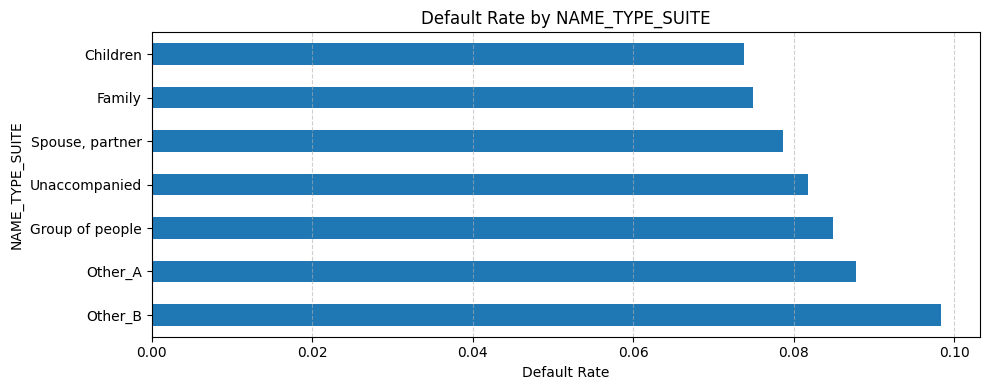

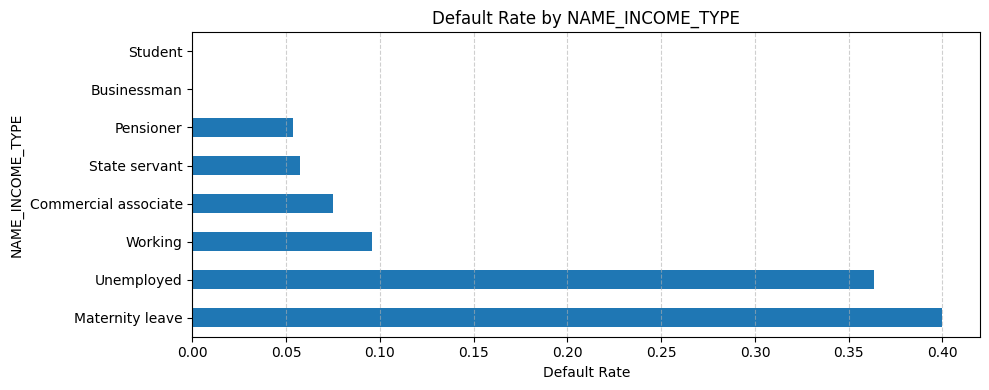

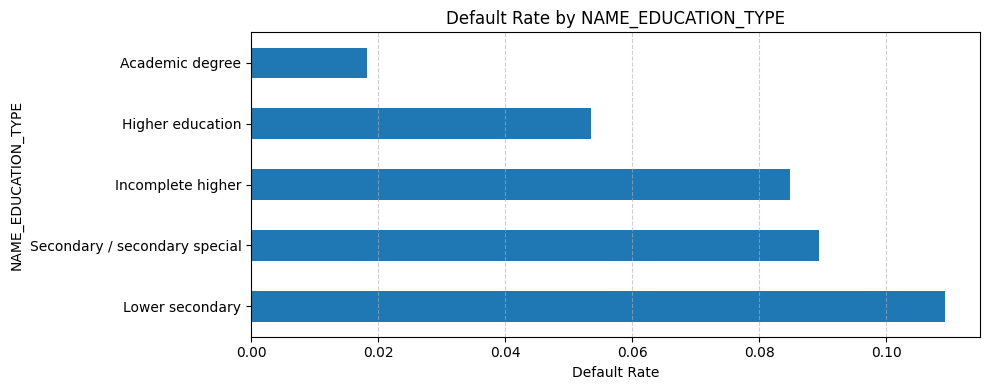

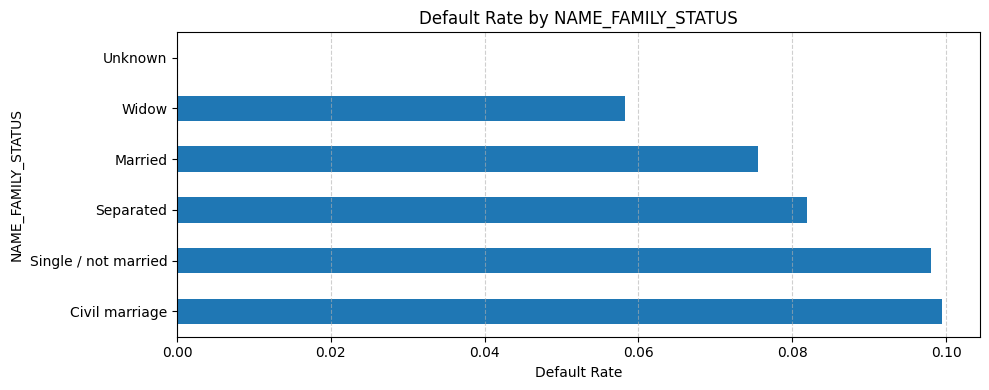

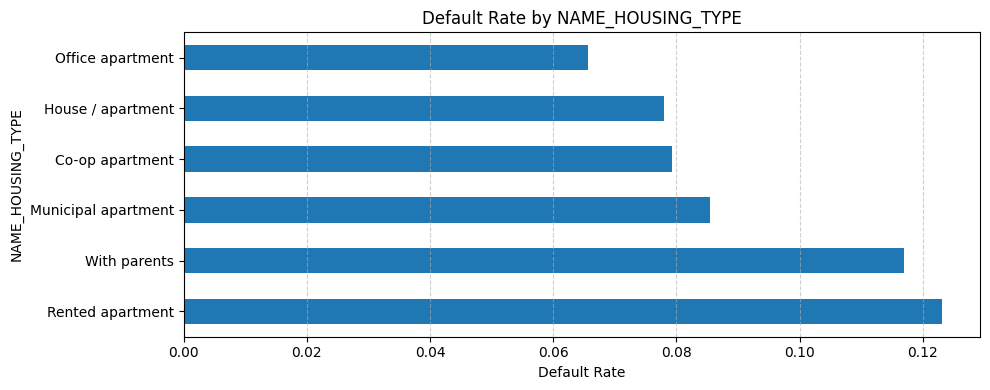

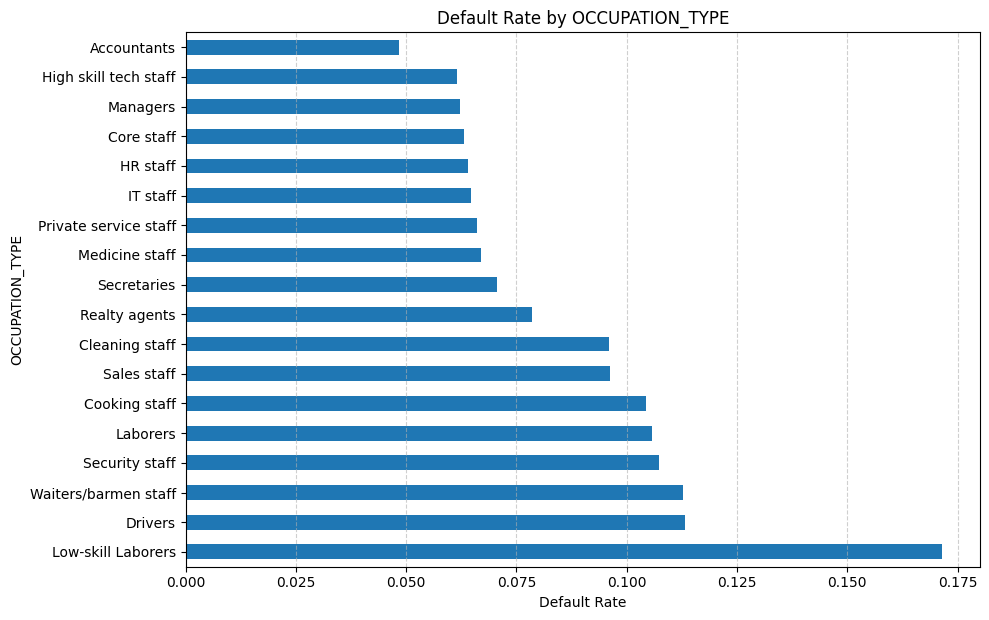

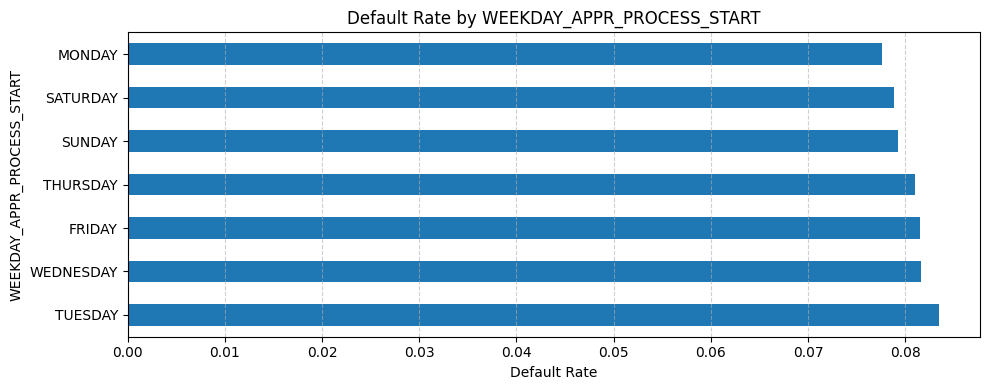

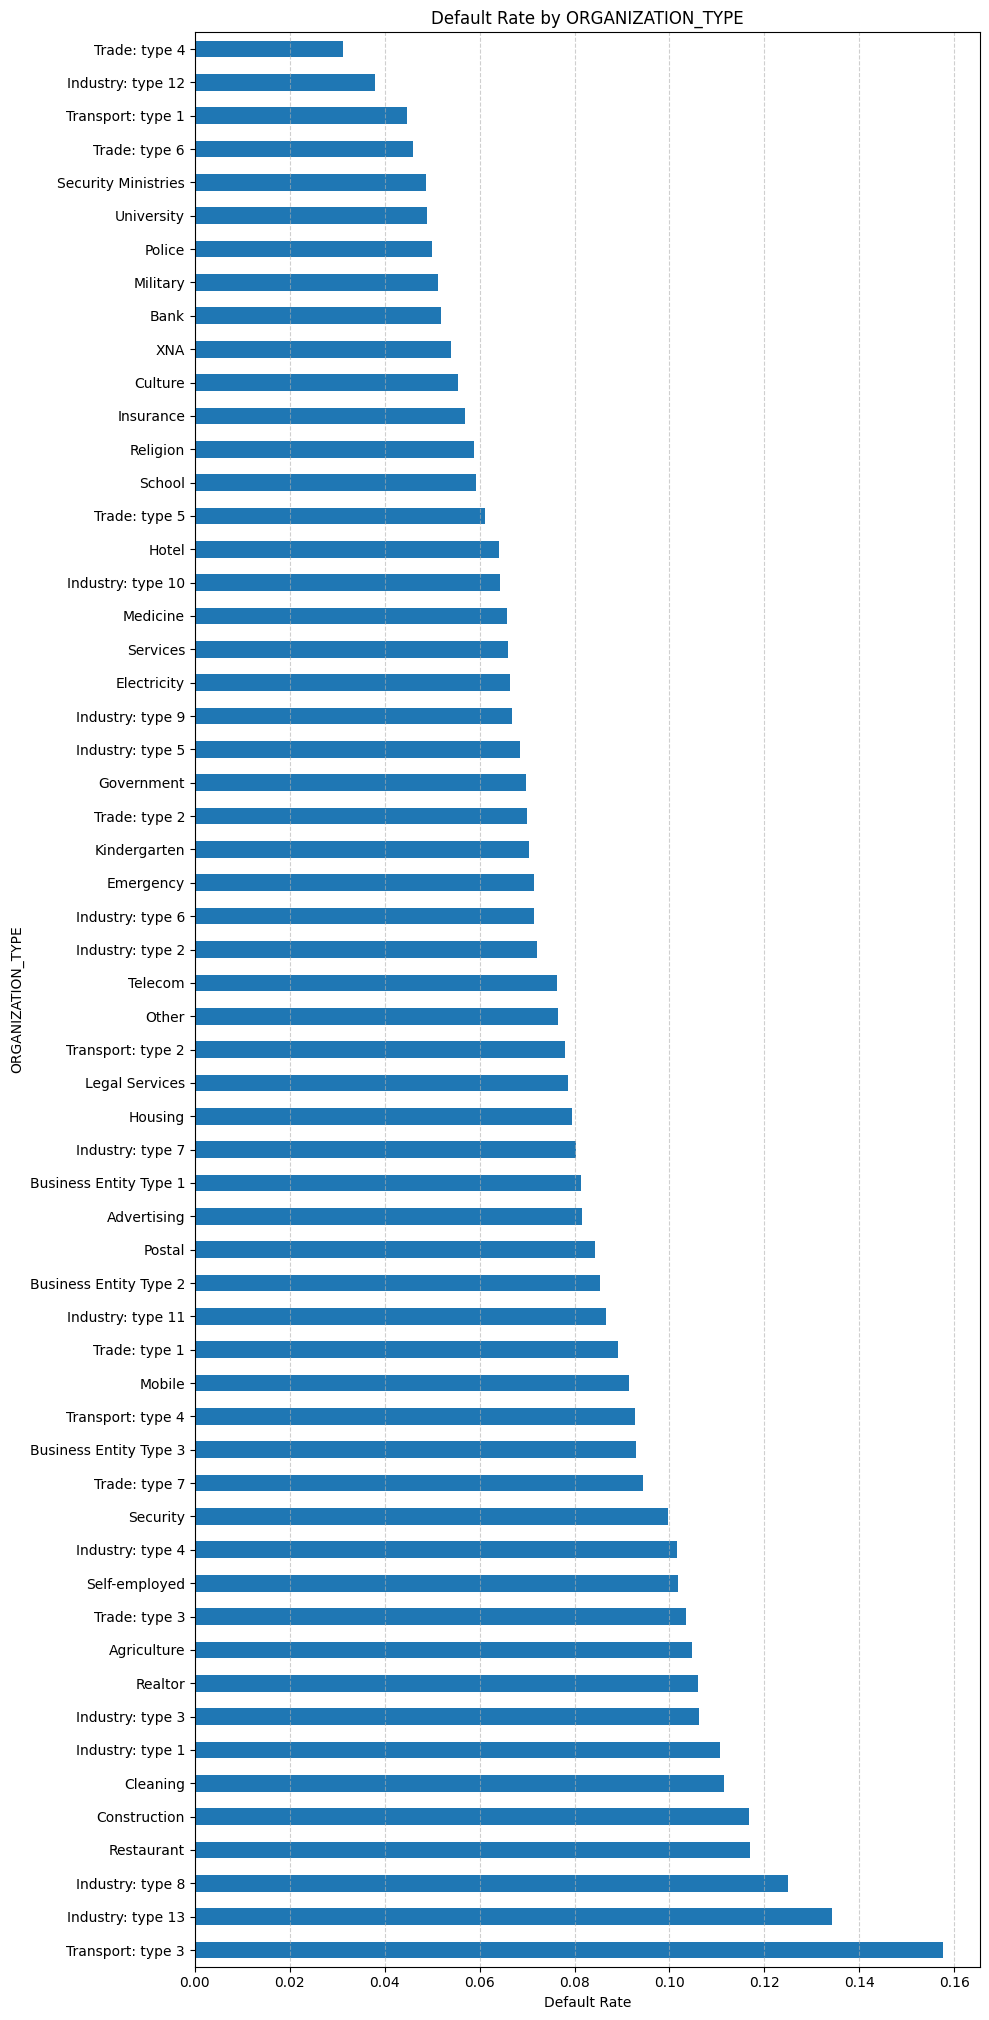

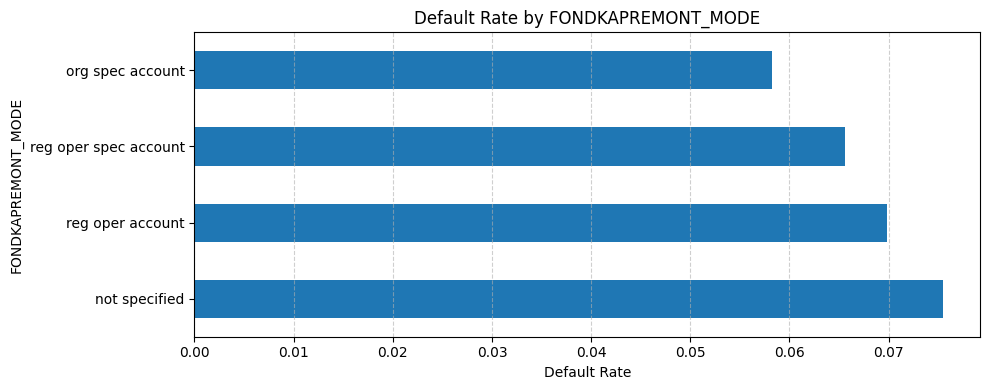

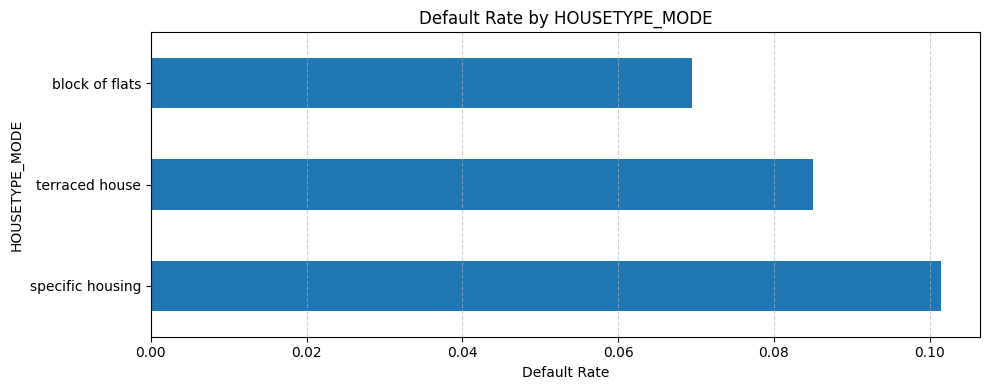

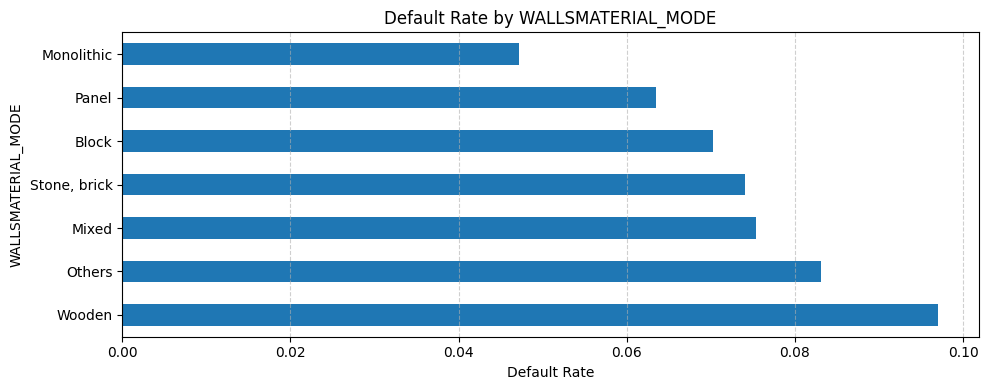

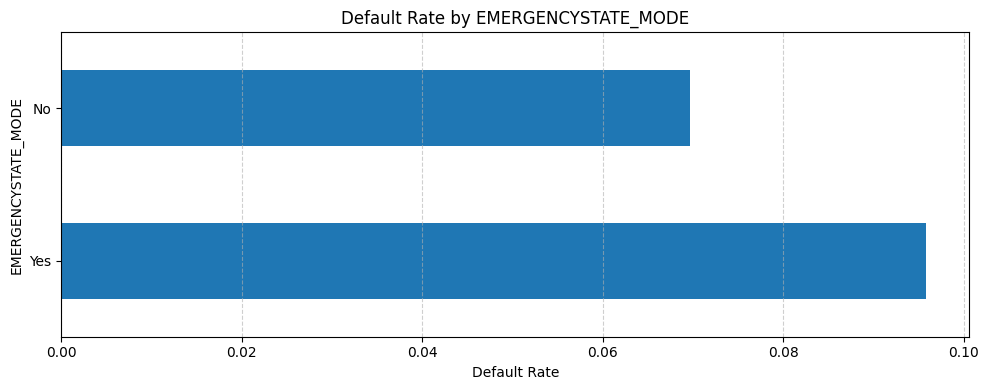

In [17]:
# Default Rate Risk


for col in categorical_features:

    default_rate = (
        df.groupby(col)['TARGET']
          .mean()
          .sort_values(ascending=False)
    )

    height = max(4, len(default_rate) * 0.35)

    plt.figure(figsize=(10, height))

    default_rate.plot(kind='barh')

    plt.xlabel('Default Rate')
    plt.ylabel(col)
    plt.title(f'Default Rate by {col}')

    plt.grid(axis='x', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [18]:
# Drop rows where CODE_GENDER is 'XNA' using index
df.drop(df[df['CODE_GENDER'] == 'XNA'].index, inplace=True)

In [19]:
for col in categorical_features:

    sample_size = (
        df[col]
        .value_counts()
        .rename('Sample_Size')
        .to_frame()
    )

In [20]:
for col in categorical_features:

    summary = (
        df.groupby(col)['TARGET']
          .agg(
              Default_Rate='mean',
              Sample_Size='count'
          )
          .sort_values('Default_Rate', ascending=False)
    )

    # Convert default rate to percentage
    summary['Default_Rate'] = (
        summary['Default_Rate'] * 100
    ).round(2)

    # Rename index
    summary.index.name = 'Category'

    print(f"\n{'=' * 60}")
    print(f"{col}")
    print(f"{'=' * 60}")

    display(summary)


NAME_CONTRACT_TYPE


,Default_Rate,Sample_Size
Category,,
Cash loans,8.35,278232
Revolving loans,5.48,29275



CODE_GENDER


,Default_Rate,Sample_Size
Category,,
M,10.14,105059
F,7.00,202448



FLAG_OWN_CAR


...

,Default_Rate,Sample_Size
Category,,
specific housing,10.14,1499
terraced house,8.50,1212
block of flats,6.94,150500



WALLSMATERIAL_MODE


,Default_Rate,Sample_Size
Category,,
Wooden,9.70,5362
Others,8.31,1625
Mixed,7.53,2296
"Stone, brick",7.41,64813
Block,7.02,9253
Panel,6.35,66039
Monolithic,4.72,1779



EMERGENCYSTATE_MODE


,Default_Rate,Sample_Size
Category,,
Yes,9.58,2328
No,6.97,159425


####  High-Risk Alerts (Top Default Indicators)

These features show massive variance in default rates. They contain incredibly strong signals that our predictive models will heavily rely on.

* **OCCUPATION_TYPE**: **Low-skill Laborers** default at a staggering **17.15%**, whereas **Accountants** default at only **4.83%**. Drivers and security staff are also significantly higher risk (>10.7%).

* **NAME_INCOME_TYPE**: Though sample sizes are small, applicants on **Maternity leave** (**40.00%**) and the **Unemployed** (**36.36%**) show critical default rates. Conversely, **Pensioners** (**5.39%**) and **State servants** (**5.75%**) are highly stable.

* **ORGANIZATION_TYPE**: Employment sectors introduce extreme risk variance. **Transport: type 3** (**15.75%**), **Industry: type 13** (**13.43%**), and **Construction** (**11.68%**) represent maximum credit risk.

* **NAME_HOUSING_TYPE**: Applicants living in **Rented apartments** (**12.31%**) or **With parents** (**11.70%**) default far more often than those who own a **House/apartment** (**7.80%**).

* **NAME_EDUCATION_TYPE**: Clear inverse correlation with risk. **Lower secondary** education correlates to a **10.93%** default rate, plummeting down to **1.83%** for individuals holding an **Academic degree**.


## Feature Engineering

In [21]:
# Income per Family Member
df['INCOME_PER_FAMILY_MEMBER'] = (
    df['AMT_INCOME_TOTAL'] /
    df['CNT_FAM_MEMBERS'].replace(0, np.nan)
)

# Credit-to-Income Ratio
df['CREDIT_INCOME_RATIO'] = (
    df['AMT_CREDIT'] /
    df['AMT_INCOME_TOTAL'].replace(0, np.nan)
)

# Annuity-to-Income Ratio
df['ANNUITY_INCOME_RATIO'] = (
    df['AMT_ANNUITY'] /
    df['AMT_INCOME_TOTAL'].replace(0, np.nan)
)

# Annuity-to-Credit Ratio
df['ANNUITY_CREDIT_RATIO'] = (
    df['AMT_ANNUITY'] /
    df['AMT_CREDIT'].replace(0, np.nan)
)


To capture additional financial relationships that may be useful for predicting loan default, several ratio-based features were created from the existing variables.

- **Income per Family Member:** Measures the approximate income available per family member, providing a better view of household financial capacity than total income alone.

- **Credit-to-Income Ratio:** Measures the loan amount relative to the applicant's income. A higher ratio may indicate a greater financial burden and potentially higher default risk.

- **Annuity-to-Income Ratio:** Measures the annual loan payment relative to the applicant's income. A higher ratio indicates a greater repayment burden compared with the applicant's income.

- **Annuity-to-Credit Ratio:** Represents the annual loan payment relative to the total credit amount and may provide information about the structure and repayment terms of the loan.

Zero denominators were replaced with `NaN` before calculating the ratios to avoid division-by-zero errors. The resulting missing values will be handled later during the preprocessing stage.

In [22]:
# Train-Test Split

X = df.drop(columns=['TARGET'])
y = df['TARGET']

In [23]:
# Split the data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        drop='first',
        sparse_output=False
    ))
])

num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])

* Numerical → Median Imputation
* Categorical → Most Frequent Imputation → One-Hot Encoding

In [25]:
# Define the four models

models = {
    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),

    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    ),

    'LightGBM': LGBMClassifier(
        n_estimators=100,
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    )
}

In [26]:
trained_models = {}

results = []

for name, model in models.items():

    print(f"Training {name}...")

    # Create pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    # Predictions
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Evaluation
    results.append({
        'Model': name,
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

results_df = (
    pd.DataFrame(results)
    .sort_values('ROC-AUC', ascending=False)
    .reset_index(drop=True)
)

display(results_df)

Training Decision Tree...
Training Random Forest...
Training XGBoost...
Training LightGBM...


,Model,ROC-AUC,Recall,Precision,F1-Score
0,LightGBM,0.766036,0.016717,0.605839,0.032536
1,XGBoost,0.758487,0.043102,0.494226,0.079289
2,Random Forest,0.722564,0.002216,0.647059,0.004416
3,Decision Tree,0.543948,0.169789,0.154029,0.161525


Feature Importance

In [27]:
best_model = trained_models['LightGBM']

lgbm_model = best_model.named_steps['model']

In [28]:
feature_names = (
    best_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

In [29]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': lgbm_model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

importance_df.head(20)

,Feature,Importance
0,num__ANNUITY_CREDIT_RATIO,315
1,num__EXT_SOURCE_1,224
2,num__EXT_SOURCE_3,204
3,num__EXT_SOURCE_2,159
4,num__AGE,146
5,num__YEARS_EMPLOYED,116
6,num__DAYS_ID_PUBLISH,106
7,num__AMT_GOODS_PRICE,88
8,num__AMT_ANNUITY,88
9,num__AMT_CREDIT,87


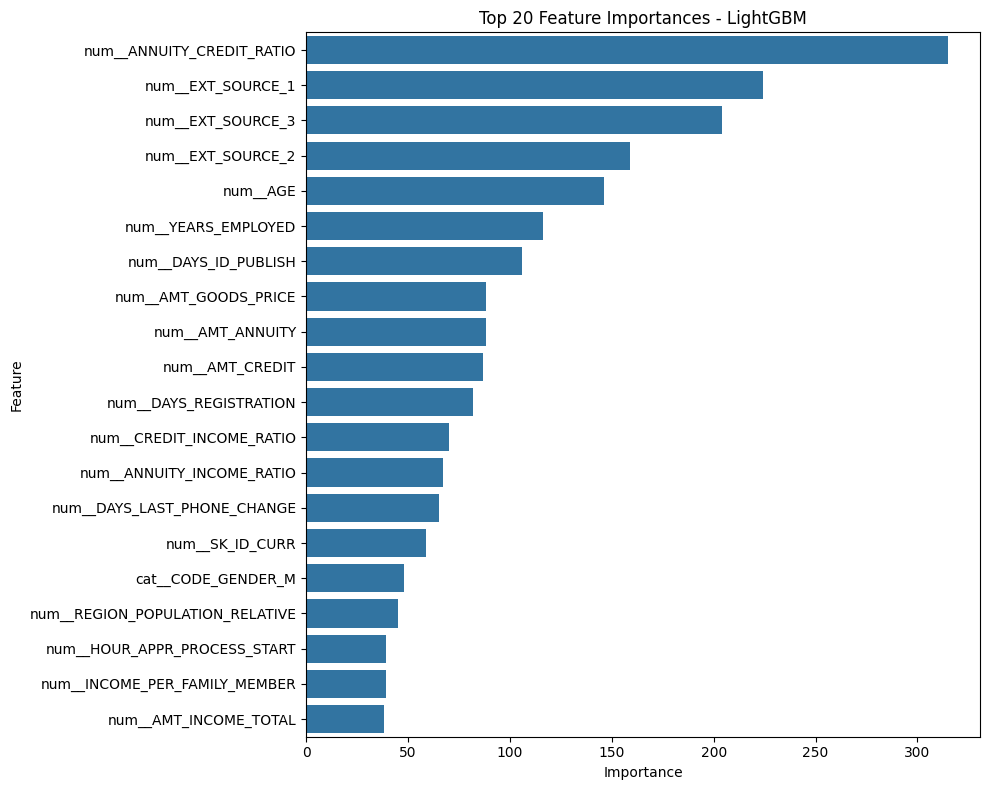

In [30]:
top_features = importance_df.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top 20 Feature Importances - LightGBM')
plt.tight_layout()
plt.show()

In [31]:
# Saveing cleaned dataframe to a CSV file
df.to_csv('cleaned_application_train.csv', index=False)